# ResNet50 — NIH ChestX-ray14
**Multi-Label Thoracic Disease Classification | Baseline Model**

In [1]:
import os, glob, time, copy, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from PIL import Image
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

import torch
import torch.nn as nn
import torch.optim as optim
import torch.cuda.amp as amp
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True  # auto-optimise GPU kernels

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch : {torch.__version__}")
print(f"Device  : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch : 2.10.0+cu128
Device  : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB


## 1. Data Loading

In [2]:
# 1. First check for Kaggle environment
if os.path.exists('/kaggle/input/datasets/organizations/nih-chest-xrays/data'):
    DATA_DIR = '/kaggle/input/datasets/organizations/nih-chest-xrays/data'
    print("Running on Kaggle")
else:
    try:
        # 2. Then check for Google Colab
        from google.colab import drive
        drive.mount('/content/drive', force_remount=True)
        DATA_DIR = '/content/drive/MyDrive/dataset for project'
        print("Running on Colab")
    except ImportError:
        # 3. Fallback to Local
        DATA_DIR = './dataset for project'   # change to your local path
        print("Running locally")

# Build filename → full path dict
all_image_paths = {}
# Using "images_*" handles both "images_001" and "images_1" styles across platforms
for subfolder in sorted(glob.glob(os.path.join(DATA_DIR, "images_*"))):
    img_folder = os.path.join(subfolder, "images")
    if os.path.exists(img_folder):
        for f in os.listdir(img_folder):
            all_image_paths[f] = os.path.join(img_folder, f)

# Load CSV and split labels
df = pd.read_csv(os.path.join(DATA_DIR, "Data_Entry_2017.csv"))
df['labels_list'] = df['Finding Labels'].str.split('|')

mlb = MultiLabelBinarizer()
label_matrix = mlb.fit_transform(df['labels_list'])
label_cols    = mlb.classes_.tolist()
DISEASE_COLS  = [c for c in label_cols if c != 'No Finding']
NUM_CLASSES   = len(DISEASE_COLS)

label_df = pd.DataFrame(label_matrix, columns=label_cols)
df = pd.concat([df.reset_index(drop=True), label_df], axis=1)

# Patient-level split — prevents data leakage (same patient in train + test)
with open(os.path.join(DATA_DIR, "train_val_list.txt")) as f:
    train_val_files = set(f.read().splitlines())
with open(os.path.join(DATA_DIR, "test_list.txt")) as f:
    test_files = set(f.read().splitlines())

df_trainval = df[df['Image Index'].isin(train_val_files)].reset_index(drop=True)
df_test     = df[df['Image Index'].isin(test_files)].reset_index(drop=True)

train_patients, val_patients = train_test_split(
    df_trainval['Patient ID'].unique(), test_size=0.1, random_state=SEED)

df_train = df_trainval[df_trainval['Patient ID'].isin(train_patients)].reset_index(drop=True)
df_val   = df_trainval[df_trainval['Patient ID'].isin(val_patients)].reset_index(drop=True)

# Safety Checks
assert len(set(df_train['Patient ID']) & set(df_val['Patient ID']))  == 0
assert len(set(df_train['Patient ID']) & set(df_test['Patient ID'])) == 0

# Class weights: pos_weight[c] = neg_count / pos_count
pos_counts         = df_train[DISEASE_COLS].sum()
neg_counts         = len(df_train) - pos_counts
pos_weight_values = (neg_counts / pos_counts).values.astype(np.float32)
pos_weight_tensor = torch.tensor(pos_weight_values).to(DEVICE)

print(f"Images  : {len(all_image_paths):,}")
print(f"Train   : {len(df_train):,}  |  Val : {len(df_val):,}  |  Test : {len(df_test):,}")

Running on Kaggle
Images  : 112,120
Train   : 77,988  |  Val : 8,536  |  Test : 25,596


## 2. Dataset & DataLoaders

In [3]:
class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, image_path_dict, label_cols, transform=None):
        self.df              = dataframe.reset_index(drop=True)
        self.image_path_dict = image_path_dict
        self.label_cols      = label_cols
        self.transform       = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(self.image_path_dict[row['Image Index']]).convert('RGB')
        if self.transform: image = self.transform(image)
        labels = torch.tensor(row[self.label_cols].values.astype(np.float32))
        return image, labels


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

BATCH_SIZE  = 128
NUM_WORKERS = 2

loader_kwargs = dict(num_workers=NUM_WORKERS, pin_memory=True,
                     persistent_workers=True, prefetch_factor=2)

train_dataset = ChestXrayDataset(df_train, all_image_paths, DISEASE_COLS, train_transform)
val_dataset   = ChestXrayDataset(df_val,   all_image_paths, DISEASE_COLS, val_test_transform)
test_dataset  = ChestXrayDataset(df_test,  all_image_paths, DISEASE_COLS, val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  **loader_kwargs)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)

print(f"Train batches : {len(train_loader)} | Val : {len(val_loader)} | Test : {len(test_loader)}")

Train batches : 610 | Val : 67 | Test : 200


## 3. Model - ResNet50
Pretrained on ImageNet. We freeze the backbone in Phase 1, then unfreeze everything in Phase 2.

In [4]:
def build_resnet50(num_classes=14):
    model = models.resnet50(pretrained=True)
    for param in model.parameters():
        param.requires_grad = False          # freeze backbone
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(model.fc.in_features, num_classes)   # replace head
    )
    return model


model = build_resnet50(NUM_CLASSES).to(DEVICE)

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total_p:,}")
print(f"Trainable now   : {trainable_p:,}  (head only — backbone frozen)")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 200MB/s]


Total params    : 23,536,718
Trainable now   : 28,686  (head only — backbone frozen)


## 4. Training Utilities

In [5]:
def unnormalize(t):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (t * std + mean).clamp(0, 1)


def compute_auc(model, loader, device, disease_cols):
    model.eval()
    all_labels, all_probs = [], []
    with torch.no_grad():
        for images, labels in loader:
            probs = torch.sigmoid(model(images.to(device)))
            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
    all_labels = np.vstack(all_labels)
    all_probs  = np.vstack(all_probs)
    per_class  = {}
    for i, d in enumerate(disease_cols):
        if all_labels[:, i].sum() > 0:
            per_class[d] = roc_auc_score(all_labels[:, i], all_probs[:, i])
        else:
            per_class[d] = float('nan')
    return np.nanmean(list(per_class.values())), per_class, all_labels, all_probs


def validate_loss(model, loader, criterion, device):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for images, labels in loader:
            total += criterion(model(images.to(device)), labels.to(device)).item()
    return total / len(loader)


def predict_sample(model, dataset, device, disease_cols, idx=None):
    if idx is None: idx = random.randint(0, len(dataset)-1)
    model.eval()
    img_t, true_lbl = dataset[idx]
    with torch.no_grad():
        prob = torch.sigmoid(model(img_t.unsqueeze(0).to(device))).squeeze().cpu().numpy()
    return img_t, true_lbl.numpy(), prob


print("Utilities defined ✓")

Utilities defined ✓


## 5. Phase 1 - Train Head Only (Backbone Frozen)
Use AMP (mixed precision) for faster GPU training.

In [6]:
criterion      = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer_p1   = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
scheduler_p1   = optim.lr_scheduler.ReduceLROnPlateau(optimizer_p1, mode='min', patience=2, factor=0.5)

# Initialize Scaler for T4 Mixed Precision
scaler = torch.cuda.amp.GradScaler()
torch.backends.cudnn.benchmark = True 

EPOCHS_P1 = 3
history   = {'train_loss': [], 'val_loss': [], 'val_auc': [], 'lr': []}
best_auc  = 0.0
best_wts  = copy.deepcopy(model.state_dict())

print(f"{'='*55}")
print(f"PHASE 1 — Head only (Using: {torch.cuda.get_device_name(0)})")
print(f"{'='*55}")

# ── 2. TRAINING LOOP ─────────────────────────────────────────────────────────
for epoch in range(1, EPOCHS_P1 + 1):
    t0 = time.time()
    model.train()
    running_loss = 0.0

    pbar = tqdm(train_loader, desc=f"E{epoch}/{EPOCHS_P1} [Phase 1]", leave=False)
    for images, labels in pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer_p1.zero_grad()
        
        # Mixed Precision (Fast Math for T4)
        with torch.cuda.amp.autocast():
            loss = criterion(model(images), labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer_p1)
        scaler.update()
        
        running_loss += loss.item()
        pbar.set_postfix(loss=f"{running_loss / (pbar.n + 1):.4f}")

    train_loss = running_loss / len(train_loader)
    val_loss   = validate_loss(model, val_loader, criterion, DEVICE)
    val_auc, _, _, _ = compute_auc(model, val_loader, DEVICE, DISEASE_COLS)
    scheduler_p1.step(val_loss)
    lr = optimizer_p1.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)
    history['lr'].append(lr)

    print(f"Epoch {epoch}/{EPOCHS_P1} | Loss {train_loss:.4f}/{val_loss:.4f} | AUC {val_auc:.4f} | LR {lr:.2e} | {(time.time()-t0)/60:.1f}m")
    if val_auc > best_auc:
        best_auc = val_auc
        best_wts = copy.deepcopy(model.state_dict())
        torch.save(best_wts, '/kaggle/working/resnet50_best.pth')
        print(f"  ✓ New best AUC {best_auc:.4f} — saved")

PHASE 1 — Head only (Using: Tesla T4)


E1/3 [Phase 1]:   0%|          | 0/610 [00:00<?, ?it/s]

Epoch 1/3 | Loss 1.2955/1.2327 | AUC 0.7121 | LR 1.00e-03 | 28.9m
  ✓ New best AUC 0.7121 — saved


E2/3 [Phase 1]:   0%|          | 0/610 [00:00<?, ?it/s]

Epoch 2/3 | Loss 1.2667/1.1948 | AUC 0.7207 | LR 1.00e-03 | 23.9m
  ✓ New best AUC 0.7207 — saved


E3/3 [Phase 1]:   0%|          | 0/610 [00:00<?, ?it/s]

Epoch 3/3 | Loss 1.2758/1.3101 | AUC 0.7256 | LR 1.00e-03 | 23.0m
  ✓ New best AUC 0.7256 — saved


## 6. Phase 2 - Full Fine-Tuning
Unfreeze entire backbone, use lower LR + AMP.

In [7]:
for param in model.parameters():
    param.requires_grad = True

optimizer_p2 = optim.Adam(model.parameters(), lr=1e-4)
scheduler_p2 = optim.lr_scheduler.CosineAnnealingLR(optimizer_p2, T_max=7, eta_min=1e-6)
scaler       = torch.cuda.amp.GradScaler()

EPOCHS_P2 = 7

print(f"{'='*55}")
print("PHASE 2 — Full fine-tuning (all layers)")
print(f"  Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"{'='*55}")

for epoch in range(1, EPOCHS_P2 + 1):
    t0 = time.time()
    model.train()
    running_loss = 0.0

    pbar = tqdm(train_loader, desc=f"E{EPOCHS_P1+epoch}/{EPOCHS_P1+EPOCHS_P2} [Phase 2]", leave=False)
    for images, labels in pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer_p2.zero_grad()
        with torch.cuda.amp.autocast():
            loss = criterion(model(images), labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer_p2); scaler.update()
        running_loss += loss.item()
        pbar.set_postfix(loss=f"{running_loss / (pbar.n + 1):.4f}")

    train_loss = running_loss / len(train_loader)
    val_loss   = validate_loss(model, val_loader, criterion, DEVICE)
    val_auc, _, _, _ = compute_auc(model, val_loader, DEVICE, DISEASE_COLS)
    scheduler_p2.step()
    lr = optimizer_p2.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)
    history['lr'].append(lr)

    print(f"Epoch {EPOCHS_P1+epoch}/{EPOCHS_P1+EPOCHS_P2} | Loss {train_loss:.4f}/{val_loss:.4f} | AUC {val_auc:.4f} | LR {lr:.2e} | {(time.time()-t0)/60:.1f}m")
    if val_auc > best_auc:
        best_auc = val_auc
        best_wts = copy.deepcopy(model.state_dict())
        torch.save(best_wts, '/kaggle/working/resnet50_best.pth')
        print(f"  ✓ New best AUC {best_auc:.4f} — saved")

model.load_state_dict(best_wts)
print(f"\n✓ Training complete. Best val AUC = {best_auc:.4f}")

PHASE 2 — Full fine-tuning (all layers)
  Trainable params: 23,536,718


E4/10 [Phase 2]:   0%|          | 0/610 [00:00<?, ?it/s]

Epoch 4/10 | Loss 1.1936/1.0901 | AUC 0.7727 | LR 9.51e-05 | 25.3m
  ✓ New best AUC 0.7727 — saved


E5/10 [Phase 2]:   0%|          | 0/610 [00:00<?, ?it/s]

Epoch 5/10 | Loss 1.0632/1.0589 | AUC 0.7958 | LR 8.14e-05 | 24.0m
  ✓ New best AUC 0.7958 — saved


...

Epoch 8/10 | Loss 0.9058/1.0683 | AUC 0.8172 | LR 1.96e-05 | 25.3m
  ✓ New best AUC 0.8172 — saved


E9/10 [Phase 2]:   0%|          | 0/610 [00:00<?, ?it/s]

Epoch 9/10 | Loss 0.8607/1.0533 | AUC 0.8213 | LR 5.90e-06 | 25.1m
  ✓ New best AUC 0.8213 — saved


E10/10 [Phase 2]:   0%|          | 0/610 [00:00<?, ?it/s]

Epoch 10/10 | Loss 0.8211/1.0820 | AUC 0.8223 | LR 1.00e-06 | 24.3m
  ✓ New best AUC 0.8223 — saved

✓ Training complete. Best val AUC = 0.8223


## 7. Training Curves

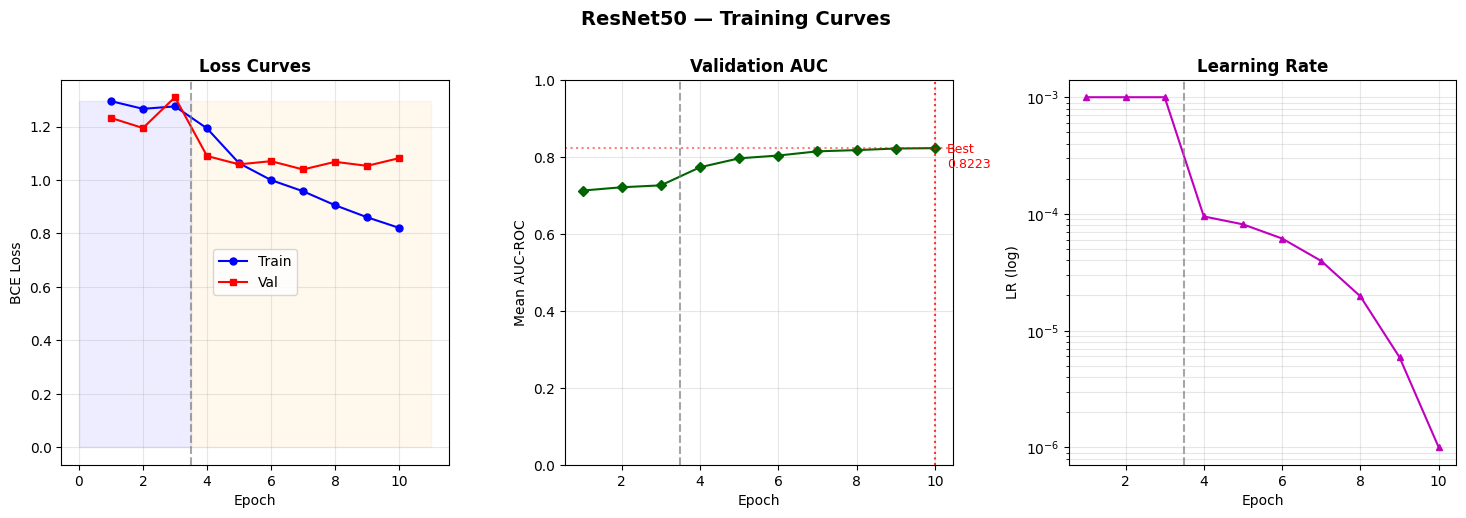

In [8]:
total_ep    = EPOCHS_P1 + EPOCHS_P2
epoch_range = list(range(1, total_ep + 1))

fig = plt.figure(figsize=(18, 5))
gs  = GridSpec(1, 3, figure=fig, wspace=0.3)

ax1 = fig.add_subplot(gs[0])
ax1.plot(epoch_range, history['train_loss'], 'b-o', ms=5, label='Train')
ax1.plot(epoch_range, history['val_loss'],   'r-s', ms=5, label='Val')
ax1.axvline(x=EPOCHS_P1+0.5, color='gray', linestyle='--', alpha=0.7)
ax1.fill_betweenx([0, max(history['train_loss'])], 0, EPOCHS_P1+0.5, alpha=0.07, color='blue')
ax1.fill_betweenx([0, max(history['train_loss'])], EPOCHS_P1+0.5, total_ep+1, alpha=0.07, color='orange')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss')
ax1.set_title('Loss Curves', fontweight='bold')
ax1.legend(); ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[1])
ax2.plot(epoch_range, history['val_auc'], color='darkgreen', marker='D', ms=5)
best_ep = history['val_auc'].index(max(history['val_auc'])) + 1
ax2.axvline(x=best_ep, color='red', linestyle=':', alpha=0.8)
ax2.axhline(y=max(history['val_auc']), color='red', linestyle=':', alpha=0.5)
ax2.axvline(x=EPOCHS_P1+0.5, color='gray', linestyle='--', alpha=0.7)
ax2.annotate(f"Best\n{max(history['val_auc']):.4f}", xy=(best_ep, max(history['val_auc'])),
             xytext=(best_ep+0.3, max(history['val_auc'])-0.05), fontsize=9, color='red')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Mean AUC-ROC')
ax2.set_title('Validation AUC', fontweight='bold')
ax2.set_ylim(0, 1); ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[2])
ax3.semilogy(epoch_range, history['lr'], 'm-^', ms=5)
ax3.axvline(x=EPOCHS_P1+0.5, color='gray', linestyle='--', alpha=0.7)
ax3.set_xlabel('Epoch'); ax3.set_ylabel('LR (log)')
ax3.set_title('Learning Rate', fontweight='bold')
ax3.grid(alpha=0.3, which='both')

fig.suptitle('ResNet50 — Training Curves', fontsize=14, fontweight='bold', y=1.02)
plt.savefig('resnet50_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Test Evaluation

In [9]:
print("Evaluating on test set...")
test_auc, per_class_auc, all_labels, all_probs = compute_auc(model, test_loader, DEVICE, DISEASE_COLS)

sorted_auc = sorted(per_class_auc.items(), key=lambda x: -x[1])

print(f"\n{'='*52}")
print(f"  {'Disease':<25} {'AUC':>8}  ")
print(f"  {'-'*38}")
for disease, auc in sorted_auc:
    flag = '✓' if auc >= 0.75 else ('~' if auc >= 0.65 else '✗')
    print(f"  {disease:<25} {auc:>7.4f}  {flag}  {'█'*int(auc*20)}")
print(f"  {'-'*38}")
print(f"  {'MEAN AUC':<25} {test_auc:>7.4f}")
print(f"{'='*52}")

Evaluating on test set...

  Disease                        AUC  
  --------------------------------------
  Hernia                     0.9092  ✓  ██████████████████
  Emphysema                  0.8989  ✓  █████████████████
  Cardiomegaly               0.8843  ✓  █████████████████
  Pneumothorax               0.8504  ✓  █████████████████
  Edema                      0.8453  ✓  ████████████████
  Effusion                   0.8159  ✓  ████████████████
  Fibrosis                   0.8076  ✓  ████████████████
  Mass                       0.7921  ✓  ███████████████
  Pleural_Thickening         0.7635  ✓  ███████████████
  Atelectasis                0.7502  ✓  ███████████████
  Consolidation              0.7338  ~  ██████████████
  Nodule                     0.7300  ~  ██████████████
  Infiltration               0.6992  ~  █████████████
  Pneumonia                  0.6988  ~  █████████████
  --------------------------------------
  MEAN AUC                   0.7985


## 9. Visualizations

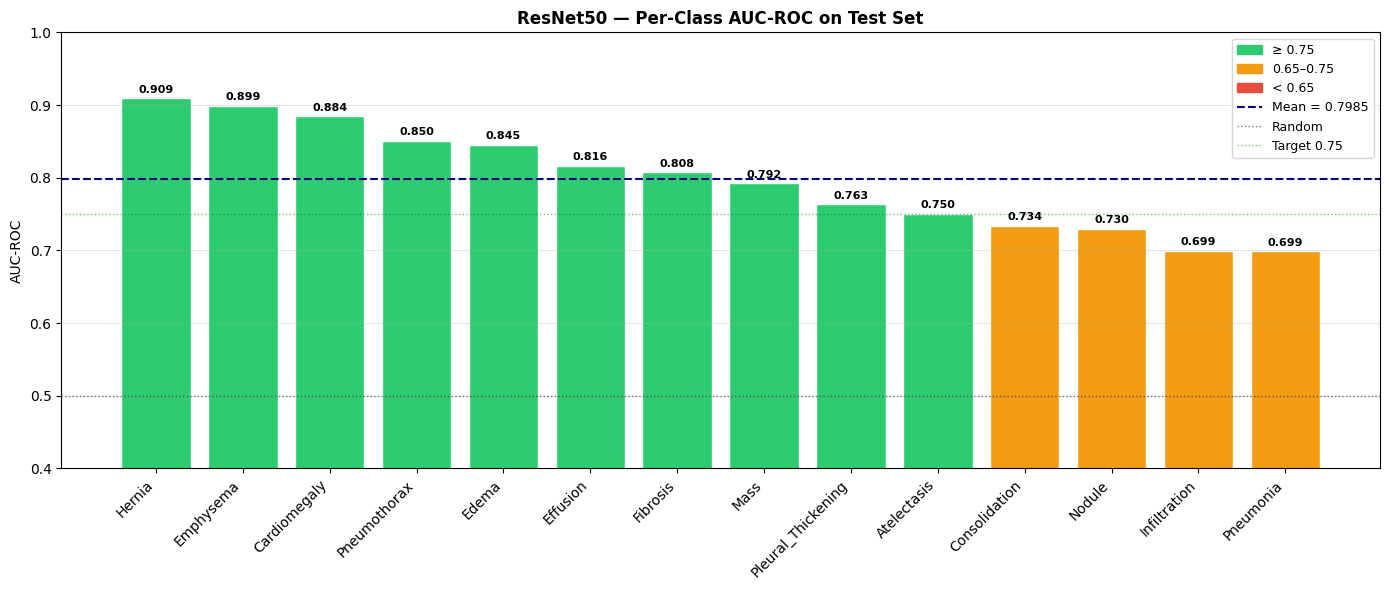

In [10]:
# Per-class AUC bar chart
diseases = [d for d, _ in sorted_auc]
aucs     = [a for _, a in sorted_auc]
colors   = ['#2ecc71' if a >= 0.75 else ('#f39c12' if a >= 0.65 else '#e74c3c') for a in aucs]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(diseases, aucs, color=colors, edgecolor='white')
for bar, auc in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{auc:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.axhline(y=test_auc, color='navy', linestyle='--', lw=1.5, label=f'Mean = {test_auc:.4f}')
ax.axhline(y=0.5,  color='black', linestyle=':', lw=1, alpha=0.5, label='Random')
ax.axhline(y=0.75, color='green', linestyle=':', lw=1, alpha=0.5, label='Target 0.75')
patches = [mpatches.Patch(color='#2ecc71', label='≥ 0.75'),
           mpatches.Patch(color='#f39c12', label='0.65–0.75'),
           mpatches.Patch(color='#e74c3c', label='< 0.65')]
ax.legend(handles=patches + ax.get_legend_handles_labels()[0][:3], fontsize=9)
ax.set_ylim(0.4, 1.0); ax.set_ylabel('AUC-ROC')
ax.set_title('ResNet50 — Per-Class AUC-ROC on Test Set', fontweight='bold')
ax.set_xticklabels(diseases, rotation=45, ha='right'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('resnet50_per_class_auc.png', dpi=150, bbox_inches='tight')
plt.show()

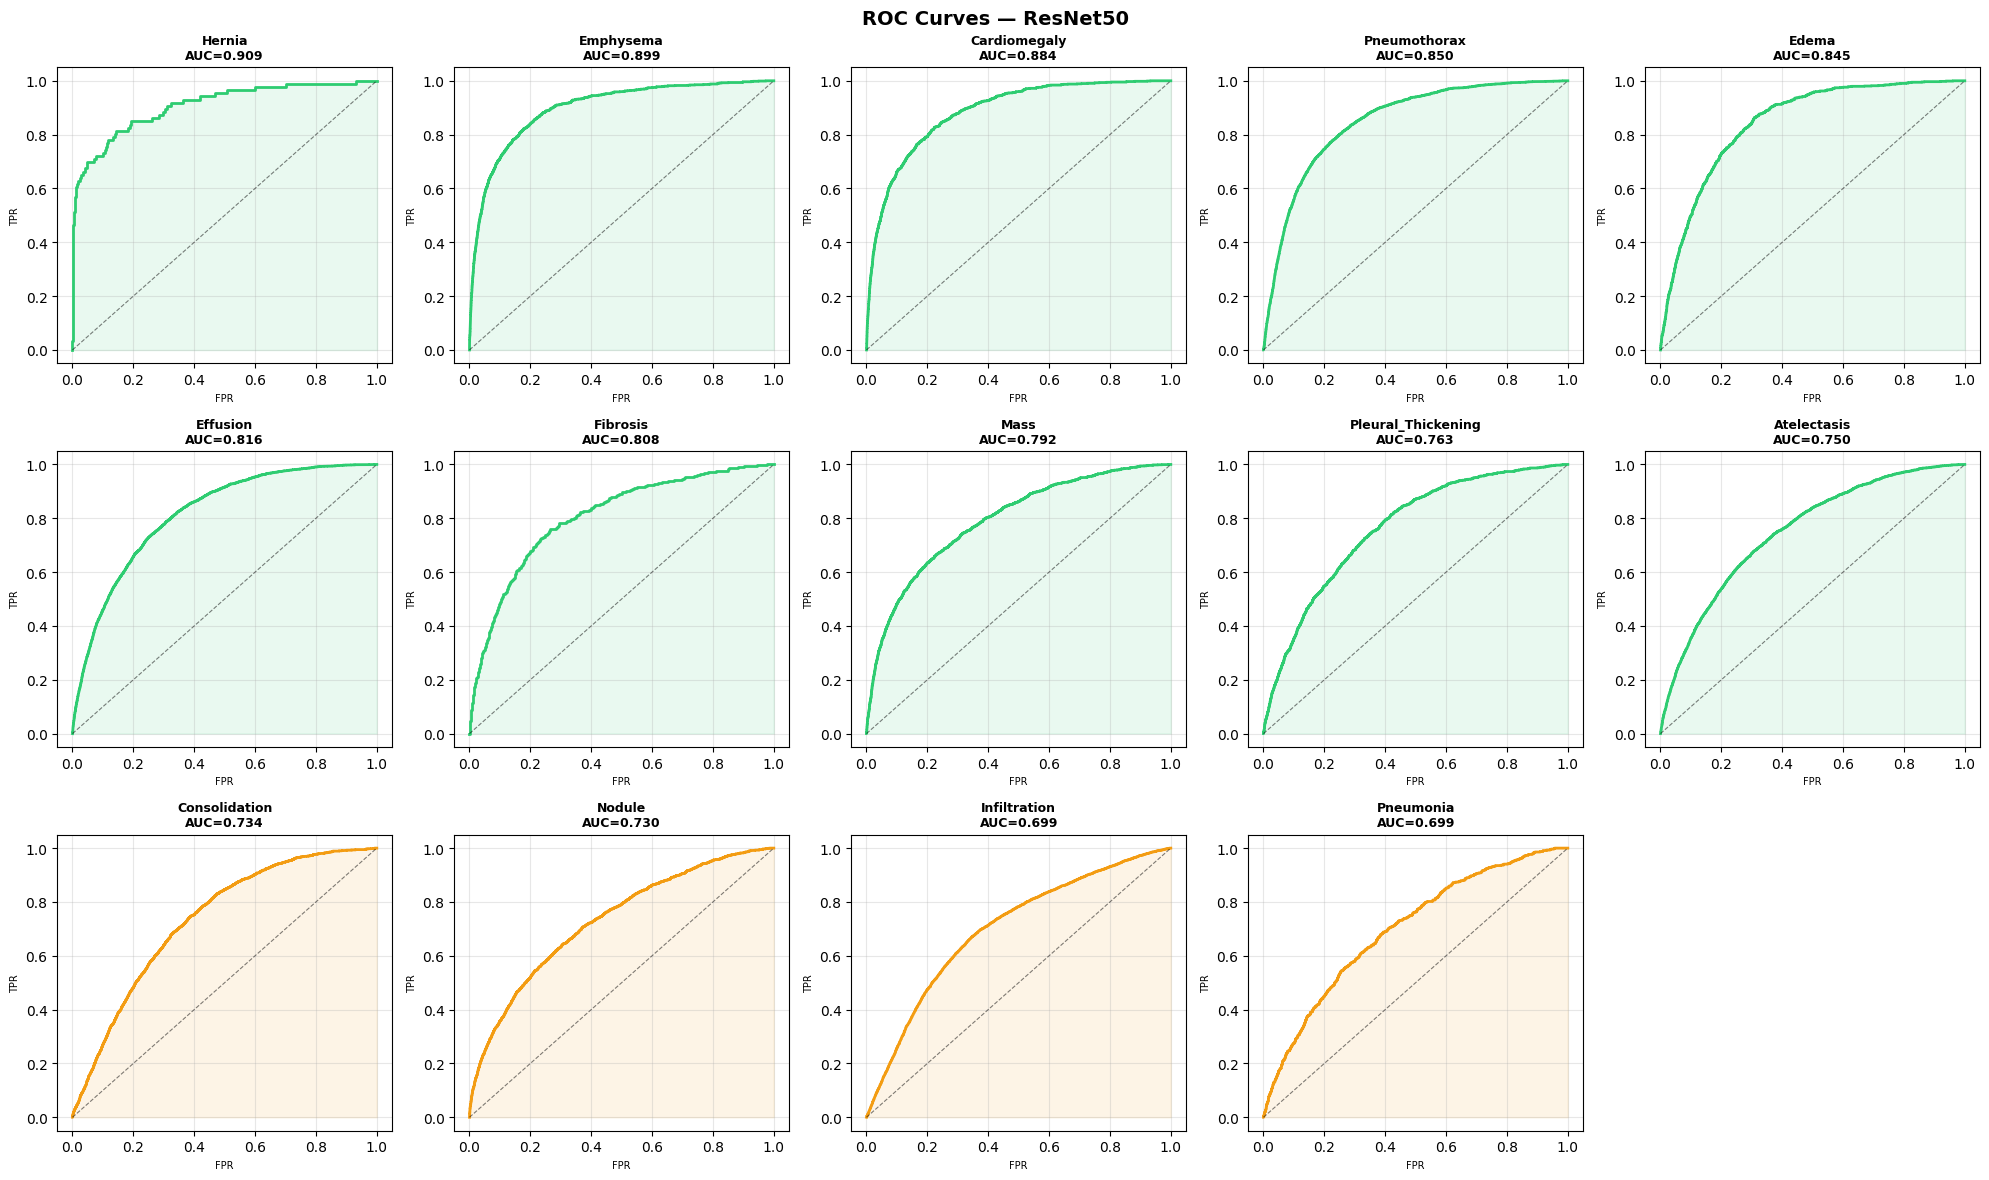

In [11]:
# ROC curves — all 14 diseases
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle('ROC Curves — ResNet50', fontsize=14, fontweight='bold')

for ax, (disease, auc_score) in zip(axes.flat, sorted_auc):
    i = DISEASE_COLS.index(disease)
    fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
    color = '#2ecc71' if auc_score >= 0.75 else ('#f39c12' if auc_score >= 0.65 else '#e74c3c')
    ax.plot(fpr, tpr, color=color, lw=2)
    ax.plot([0,1],[0,1], 'k--', lw=0.8, alpha=0.5)
    ax.fill_between(fpr, tpr, alpha=0.1, color=color)
    ax.set_title(f'{disease}\nAUC={auc_score:.3f}', fontsize=9, fontweight='bold')
    ax.set_xlabel('FPR', fontsize=7); ax.set_ylabel('TPR', fontsize=7); ax.grid(alpha=0.3)

for ax in axes.flat[len(sorted_auc):]: ax.set_visible(False)
plt.tight_layout()
plt.savefig('resnet50_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

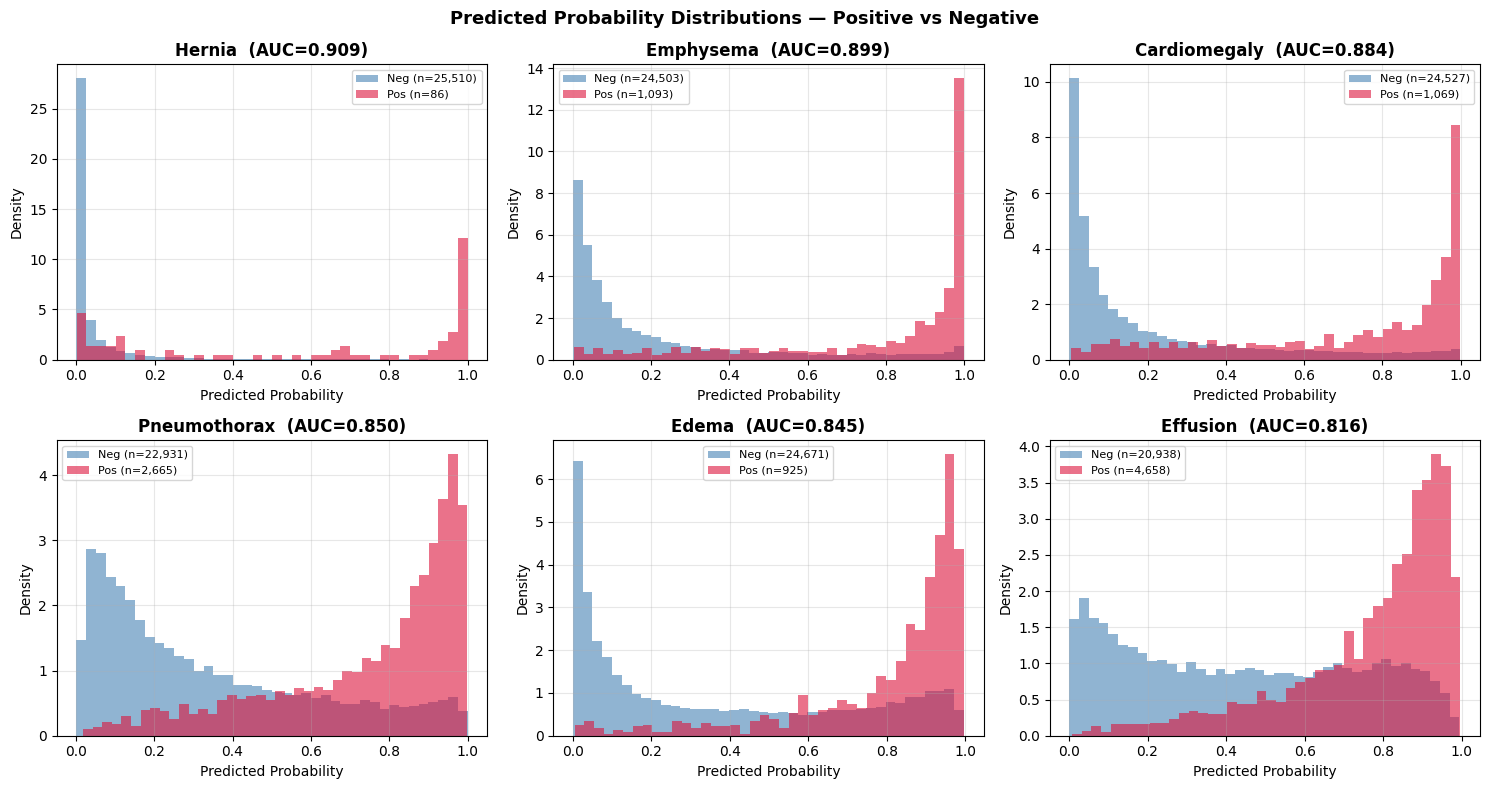

In [12]:
# Probability distributions — positive vs negative cases (top 6 diseases)
top6 = [d for d, _ in sorted_auc[:6]]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Predicted Probability Distributions — Positive vs Negative', fontsize=13, fontweight='bold')

for ax, disease in zip(axes.flat, top6):
    i = DISEASE_COLS.index(disease)
    ax.hist(all_probs[all_labels[:,i]==0, i], bins=40, alpha=0.6, color='steelblue',
            density=True, label=f'Neg (n={int((all_labels[:,i]==0).sum()):,})')
    ax.hist(all_probs[all_labels[:,i]==1, i], bins=40, alpha=0.6, color='crimson',
            density=True, label=f'Pos (n={int((all_labels[:,i]==1).sum()):,})')
    ax.set_title(f'{disease}  (AUC={per_class_auc[disease]:.3f})', fontweight='bold')
    ax.set_xlabel('Predicted Probability'); ax.set_ylabel('Density')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('resnet50_prob_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

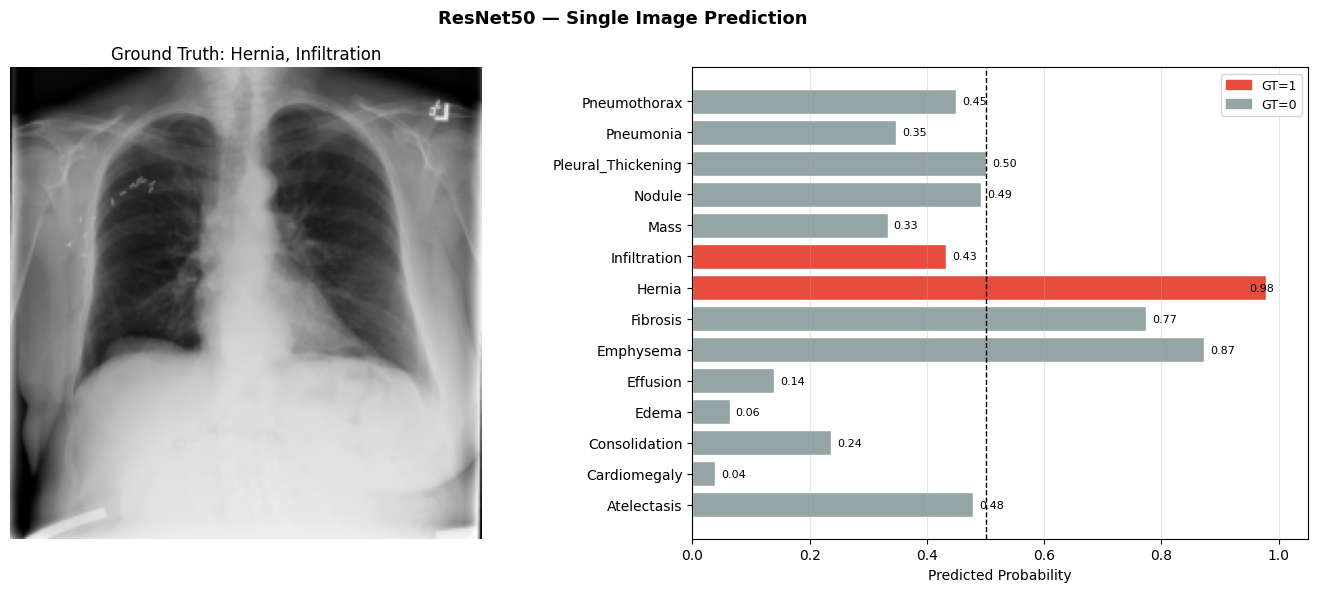

In [13]:
# Single-image prediction breakdown (multi-label image)
for i in range(len(test_dataset)):
    _, lbl, _ = predict_sample(model, test_dataset, DEVICE, DISEASE_COLS, idx=i)
    if lbl.sum() >= 2: sample_idx = i; break

img_t, true_lbl, pred_prob = predict_sample(model, test_dataset, DEVICE, DISEASE_COLS, idx=sample_idx)

fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('ResNet50 — Single Image Prediction', fontsize=13, fontweight='bold')

ax_img.imshow(unnormalize(img_t).permute(1,2,0).numpy(), cmap='bone')
gt = [DISEASE_COLS[j] for j, v in enumerate(true_lbl) if v == 1]
ax_img.set_title(f"Ground Truth: {', '.join(gt)}"); ax_img.axis('off')

bar_colors = ['#e74c3c' if true_lbl[j] == 1 else '#95a5a6' for j in range(NUM_CLASSES)]
bars = ax_bar.barh(DISEASE_COLS, pred_prob, color=bar_colors, edgecolor='white')
ax_bar.axvline(x=0.5, color='black', linestyle='--', lw=1, label='Threshold (0.5)')
for bar, prob in zip(bars, pred_prob):
    ax_bar.text(min(prob+0.01, 0.95), bar.get_y()+bar.get_height()/2,
                f'{prob:.2f}', va='center', fontsize=8)
ax_bar.legend(handles=[mpatches.Patch(color='#e74c3c', label='GT=1'),
                        mpatches.Patch(color='#95a5a6', label='GT=0')], fontsize=9)
ax_bar.set_xlabel('Predicted Probability'); ax_bar.set_xlim(0, 1.05); ax_bar.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('resnet50_single_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

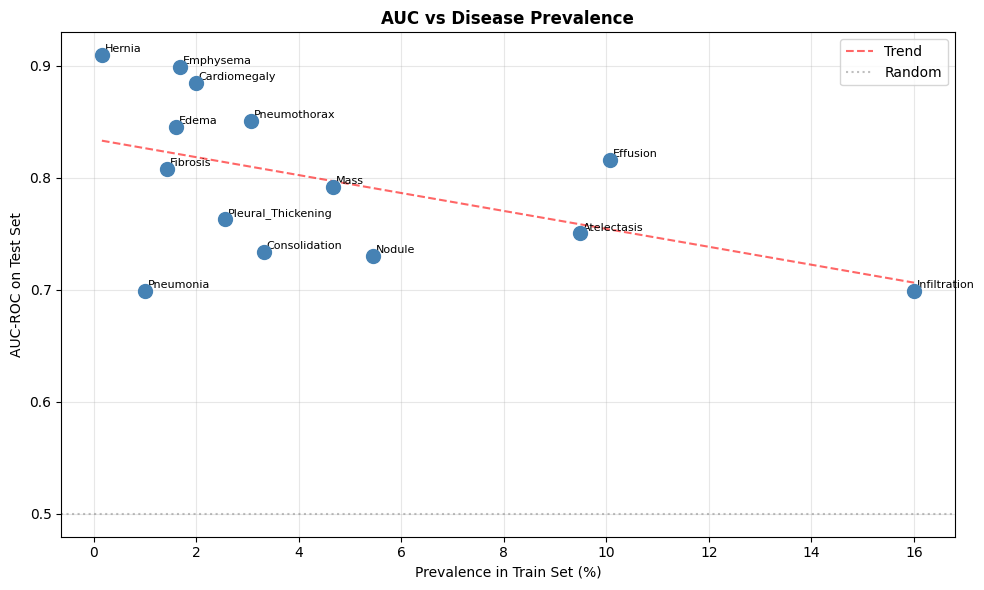

In [14]:
# AUC vs disease prevalence scatter
prevalence = df_train[DISEASE_COLS].mean() * 100
auc_series = pd.Series(per_class_auc)

fig, ax = plt.subplots(figsize=(10, 6))
for disease in DISEASE_COLS:
    ax.scatter(prevalence[disease], auc_series[disease], s=100, color='steelblue', zorder=5)
    ax.annotate(disease, xy=(prevalence[disease], auc_series[disease]),
                xytext=(2, 2), textcoords='offset points', fontsize=8)
z = np.polyfit(prevalence.values, auc_series.values, 1)
x_line = np.linspace(prevalence.min(), prevalence.max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), 'r--', alpha=0.6, label='Trend')
ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Random')
ax.set_xlabel('Prevalence in Train Set (%)'); ax.set_ylabel('AUC-ROC on Test Set')
ax.set_title('AUC vs Disease Prevalence', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('resnet50_auc_vs_prevalence.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Save Results

In [15]:
summary_df = pd.DataFrame({
    'Disease'      : DISEASE_COLS,
    'Train_Pos'    : df_train[DISEASE_COLS].sum().values,
    'Prevalence_%' : (df_train[DISEASE_COLS].mean() * 100).round(2).values,
    'Pos_Weight'   : pos_weight_values.round(1),
    'Test_AUC'     : [round(per_class_auc[d], 4) for d in DISEASE_COLS],
}).sort_values('Test_AUC', ascending=False).reset_index(drop=True)

print(summary_df.to_string(index=False))
print(f"\nMean Test AUC : {test_auc:.4f}")

summary_df.to_csv('resnet50_results.csv', index=False)
print("Saved to resnet50_results.csv")

           Disease  Train_Pos  Prevalence_%  Pos_Weight  Test_AUC
            Hernia        122          0.16  638.200012    0.9092
         Emphysema       1317          1.69   58.200001    0.8989
      Cardiomegaly       1549          1.99   49.299999    0.8843
      Pneumothorax       2394          3.07   31.600000    0.8504
             Edema       1253          1.61   61.200001    0.8453
          Effusion       7852         10.07    8.900000    0.8159
          Fibrosis       1111          1.42   69.199997    0.8076
              Mass       3646          4.68   20.400000    0.7921
Pleural_Thickening       1997          2.56   38.099998    0.7635
       Atelectasis       7405          9.50    9.500000    0.7502
     Consolidation       2584          3.31   29.200001    0.7338
            Nodule       4247          5.45   17.400000    0.7300
      Infiltration      12480         16.00    5.200000    0.6992
         Pneumonia        782          1.00   98.699997    0.6988

Mean Test